# CIFAR-10 分类 —— SimpleConvNet 自定义 CNN 模型（卷积神经网络CNN1.md）

本脚本实现了 CIFAR-10 数据集的 10 分类任务，包括：
1. 数据加载与预处理（自定义 Dataset 类读取 CSV 标签 + PNG 图片）
2. 数据探索（shape 查看、均值/标准差计算）
3. Trainer 通用训练器类（含早停、TensorBoard、绘图、回归训练）
4. SimpleConvNet 自定义 CNN 模型构建、训练与评估

## 0. 导入依赖库

In [1]:
import torch  # PyTorch 核心库，提供张量运算与自动求导
import torch.nn as nn  # 神经网络模块，提供 Conv2d、Linear、ReLU 等层
import torch.nn.functional as F  # 神经网络函数式 API，提供 relu、max_pool2d 等函数
import torch.optim as optim  # 优化器模块，提供 SGD、Adam 等
from torchvision import transforms  # transforms: 数据预处理（Resize、ToTensor、Normalize 等）
from torch.utils.data import Dataset, DataLoader  # Dataset: 自定义数据集基类；DataLoader: 批量加载器
import matplotlib.pyplot as plt  # 绘图库，用于训练曲线绘制
import os  # 操作系统接口，用于路径拼接、文件判断
import pandas as pd  # 数据处理库，用于读取 CSV 标签文件
from PIL import Image  # PIL 图像处理库，用于加载 PNG/JPG 图片
from torch.utils.tensorboard import SummaryWriter  # TensorBoard 写入器，用于记录训练日志

## 1. 数据路径配置

In [2]:
# 数据集目录结构:
#   data/cifar-10/
#     train/train/          ← 训练图片目录（50,000 张 PNG）
#       1.png, 2.png, ...
#     trainLabels.csv       ← 训练集标签文件 (id, label)
#     test/test/            ← 测试图片目录（300,000 张 PNG）
#       1.png, 2.png, ...
#     sampleSubmission.csv  ← 提交样例文件 (id, label)

# 训练图片主目录: 存放 50,000 张 PNG 图片
data_dir = './data/cifar-10/train/train'  # 训练图片所在文件夹路径
# 训练标签 CSV 文件路径: 包含 id 和 label 两列
label_csv = './data/cifar-10/trainLabels.csv'  # 标签文件路径

## 2. 读取标签并划分训练集/验证集

In [3]:
# 使用 pandas 读取全部标签 CSV 文件
labels_df = pd.read_csv(label_csv)  # 读取 trainLabels.csv，包含 id 和 label 列
train_size = 45000  # 训练集大小: 前 45,000 张用于训练
val_size = 5000  # 验证集大小: 后 5,000 张用于验证

In [4]:
# 断言检查: 确保数据量足够划分
assert train_size + val_size <= len(labels_df), "数据集图片数量不足！"  # 数据量不足时报错

In [5]:
# 划分训练集标签: 取前 45000 行，重置索引（drop=True 丢弃旧索引）
train_labels_df = labels_df.iloc[:train_size].reset_index(drop=True)  # 训练集标签 DataFrame
# 划分验证集标签: 取 45000~50000 行，重置索引
val_labels_df = labels_df.iloc[train_size:train_size + val_size].reset_index(drop=True)  # 验证集标签 DataFrame

In [6]:
# 基于全部标签建立类别映射，保证训练/验证/测试类别一致
class_names = sorted(labels_df['label'].unique())  # 获取所有唯一的类别名称并按字母排序
# 建立类别名称 → 整数索引的映射字典
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}  # 如 {'airplane': 0, 'automobile': 1, ...}
# 打印类别映射关系，便于确认
print("类别映射:", class_to_idx)  # 输出 10 个类别的名称与索引对应关系

类别映射: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


## 3. 数据预处理定义 (transforms)

### 3.1 各通道均值/标准差的计算过程（确定 Normalize 参数）

Normalize 的 (mean, std) 是训练集各通道的像素统计量，计算方式:

    mean_c = (1/(N·H·W)) Σ x_c             # 各通道像素均值
    std_c  = √(Σ x_c²/(N·H·W) − mean_c²)   # 各通道像素标准差

其中 N=45,000（训练子集），每张 32×32，需在 ToTensor 归一化到 [0,1] 之后统计。
运行下方代码得到: mean ≈ (0.4915, 0.4821, 0.4464)，std ≈ (0.2472, 0.2437, 0.2617)

In [7]:
# 计算训练集各通道的均值与标准差（用于确定下方 Normalize 参数）
# 注意: 需遍历 45000 张图片，运行约 1~2 分钟；只需运行一次，把结果固化到 Normalize 即可

# 训练子集 = 前 45000 张（与 2. 节划分一致），每张 32×32 彩色图
N = 45000      # 参与统计的图片数
pix = 32 * 32  # 每张图每通道的像素数

# 用累加方式流式统计，避免一次性把 45000 张图堆叠成大张量（省内存）
sum_c = torch.zeros(3)      # 各通道像素累加和
sumsq_c = torch.zeros(3)    # 各通道像素平方累加和

for img_number in range(1, N + 1):
    img = Image.open(os.path.join(data_dir, f'{img_number}.png')).convert('RGB')  # 打开第 img_number 张图
    t = transforms.ToTensor()(img)  # 归一化到 [0,1]，shape (3, 32, 32)
    sum_c += t.sum(dim=(1, 2))        # 累加各通道像素和
    sumsq_c += (t ** 2).sum(dim=(1, 2))  # 累加各通道像素平方和

# mean = Σx / (N·H·W)；std = √(E[x²] − mean²)
mean = sum_c / (N * pix)                             # (3,) 各通道均值
std = torch.sqrt(sumsq_c / (N * pix) - mean ** 2)    # (3,) 各通道标准差

print("mean:", [round(m, 4) for m in mean.tolist()])  # 约 [0.4915, 0.4821, 0.4464]
print("std :", [round(s, 4) for s in std.tolist()])   # 约 [0.2472, 0.2437, 0.2617]

mean: [0.4915, 0.4821, 0.4464]
std : [0.2472, 0.2437, 0.2617]


In [8]:
# 训练集数据增强: 随机翻转 + 随机裁剪 + 转 Tensor + 标准化
# transforms.Compose: 将多个 transform 操作组合在一起，按顺序依次执行
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # 随机水平翻转: 以 50% 概率水平翻转图片（数据增强）
    transforms.RandomCrop(32, padding=4),  # 随机裁剪: 先四周各补 4 像素 0，再随机裁出 32×32（数据增强）
    transforms.ToTensor(),  # 将 PIL.Image (0-255) 转为 torch.Tensor (0.0-1.0)，并将 H×W×C → C×H×W
    # 标准化: (x - mean) / std，使用上方 3.1 节计算得到的训练集通道均值与标准差
    transforms.Normalize((0.4915, 0.4821, 0.4464), (0.2472, 0.2437, 0.2617))  # 三通道分别标准化
])

In [9]:
# 验证集预处理: 只做转 Tensor + 标准化，不做数据增强
val_transform = transforms.Compose([
    transforms.ToTensor(),  # PIL.Image → Tensor (0.0-1.0)
    transforms.Normalize((0.4915, 0.4821, 0.4464), (0.2472, 0.2437, 0.2617))  # 与训练集使用相同的标准化参数
])

## 4. 自定义 Dataset 类 —— CIFAR10WithCSV
由于 CIFAR-10 的图片以数字 ID 命名（如 1.png），标签单独存于 CSV，
无法直接使用 torchvision 的 ImageFolder，需要自定义 Dataset 类

In [10]:
class CIFAR10WithCSV(Dataset):
    """
    自定义 CIFAR-10 数据集类: 根据 DataFrame 子集读取图片与标签

    与 ImageFolder 不同，图片文件名是数字 ID（1.png, 2.png, ...），
    标签来自外部 CSV 文件（trainLabels.csv），而非文件夹名。
    """

    def __init__(self, img_dir, labels_frame, class_to_idx, transform=None):
        """
        初始化数据集

        参数:
            img_dir:       图片存放目录路径
            labels_frame:  包含 (id, label) 两列的 pandas DataFrame
            class_to_idx:  类别名称 → 索引的映射字典
            transform:     数据预处理变换（Compose 对象），默认为 None
        """
        self.img_dir = img_dir  # 保存图片目录路径
        self.labels_frame = labels_frame  # 保存标签 DataFrame
        self.class_to_idx = class_to_idx  # 保存类别映射字典
        self.transform = transform  # 保存预处理变换

    def __len__(self):
        """返回数据集样本总数"""
        return len(self.labels_frame)  # DataFrame 的行数即为样本数

    def __getitem__(self, idx):
        """
        获取第 idx 个样本

        参数:
            idx: 样本索引（0 ~ len-1）
        返回:
            (image, label): 预处理后的图片张量和对应的整数标签
        """
        # 第 idx 行第 0 列: 图片的文件名数字 ID（如 1, 2, 3, ...）
        img_number = str(self.labels_frame.iloc[idx, 0])  # 转为字符串用于路径拼接
        # 拼接完整图片路径: 目录 + 文件名 + .png 扩展名
        img_name = os.path.join(self.img_dir, img_number + '.png')  # 完整路径如 '../data/cifar-10/train/train/1.png'
        # 用 PIL 打开图片并转为 RGB 三通道（处理可能的灰度图或 RGBA 图）
        image = Image.open(img_name).convert('RGB')  # 加载为 RGB 格式的 PIL.Image 对象
        # 第 idx 行第 1 列: 类别名称字符串（如 'cat', 'dog'）
        label_name = self.labels_frame.iloc[idx, 1]  # 获取类别名称
        # 通过映射字典将类别名称转为整数索引
        label = self.class_to_idx[label_name]  # 如 'cat' → 3
        # 如果有预处理变换，则应用变换
        if self.transform:  # transform 不为 None
            image = self.transform(image)  # 对图片应用预处理（ToTensor + Normalize 等）
        return image, label  # 返回 (图片张量, 整数标签)


# 构建训练集 Dataset 实例
train_dataset = CIFAR10WithCSV(
    data_dir,  # 图片目录
    train_labels_df,  # 训练集标签 DataFrame (前 45000 行)
    class_to_idx,  # 类别映射字典
    transform=train_transform  # 训练集预处理（含数据增强）
)

In [11]:
# 构建验证集 Dataset 实例
val_dataset = CIFAR10WithCSV(
    data_dir,  # 图片目录（与训练集共享同一图片文件夹）
    val_labels_df,  # 验证集标签 DataFrame (后 5000 行)
    class_to_idx,  # 类别映射字典（与训练集一致）
    transform=val_transform  # 验证集预处理（仅标准化，无数据增强）
)

## 5. 创建 DataLoader

In [12]:
# 训练集 DataLoader: shuffle=True 打乱样本顺序，pin_memory=True 加速 GPU 传输
train_loader = DataLoader(
    train_dataset,  # 训练集 Dataset 实例
    batch_size=128,  # 每批 128 张图片（可根据显存调整）
    shuffle=True,  # 每个 epoch 随机打乱样本顺序，防止模型记忆数据顺序
    pin_memory=True  # 将数据放入 CUDA 固定内存，加速 CPU→GPU 传输
)

In [13]:
# 验证集 DataLoader: shuffle=False 不打乱，保持评估的一致性
val_loader = DataLoader(
    val_dataset,  # 验证集 Dataset 实例
    batch_size=128,  # 每批 128 张图片
    shuffle=False,  # 验证/测试时不需打乱顺序
    pin_memory=True  # 加速 GPU 数据传输
)

## 6. 数据探索

In [14]:
# 查看单个样本图片张量的形状: (C, H, W) = (3, 32, 32)
print("单张图片 shape (C, H, W):", train_dataset[0][0].shape)  # torch.Size([3, 32, 32])
# 查看单个样本的标签: 0~9 的整数
print("第一张图片的标签编号:", train_dataset[0][1])  # 如 6 (frog)

单张图片 shape (C, H, W): torch.Size([3, 32, 32])
第一张图片的标签编号: 6


In [15]:
# 查看一个 batch 的数据形状
# 注意: 如果没有 GPU 可能会显示警告，这是正常的
for images, labels in train_loader:  # 取训练集第一个 batch
    print("一个 batch 的图片 shape:", images.shape)  # torch.Size([128, 3, 32, 32])
    print("一个 batch 的标签 shape:", labels.shape)  # torch.Size([128])
    break  # 只取第一个 batch

一个 batch 的图片 shape: torch.Size([128, 3, 32, 32])
一个 batch 的标签 shape: torch.Size([128])


## 7. Trainer 通用训练器类
该类封装了完整的训练流水线: 训练循环 + 验证评估 + 早停 + 模型保存 + TensorBoard + 绘图
同时支持分类任务（带准确率）与回归任务（仅损失）

In [16]:
class Trainer:
    """
    通用训练器：封装训练循环、评估、早停、模型保存与可视化

    支持两种任务:
      - 分类: 使用 train() + evaluating()，记录损失与准确率
      - 回归: 使用 regression_train() + regression_evaluating()，仅记录损失
    """

    def __init__(
            self,
            model,  # 待训练的 PyTorch 模型实例
            trainloader,  # 训练集 DataLoader
            valloader,  # 验证集 DataLoader
            criterion,  # 损失函数（如 CrossEntropyLoss）
            optimizer,  # 优化器（如 Adam、SGD）
            device='cuda',  # 训练设备: 'cuda'（GPU）或 'cpu'
            epochs=10,  # 最大训练轮数，默认 10
            early_stopping=True,  # 是否启用早停机制
            patience=5,  # 早停容忍度: 连续 patience 轮指标未提升则停止训练
            save_path="best_model.pth",  # 最优模型权重保存路径
            early_stop_mode="loss",  # 早停监控指标: "loss"（损失越小越好）或 "acc"（准确率）
            maximize_acc=True,  # early_stop_mode="acc" 时: True=准确率越大越好, False=越小越好
            use_tensorboard=False,  # 是否启用 TensorBoard 可视化日志
            log_dir='tensorboard_logs'  # TensorBoard 日志存放目录
    ):
        """初始化训练器，保存所有配置并创建 TensorBoard 写入器"""
        self.model = model  # 保存模型实例
        self.trainloader = trainloader  # 保存训练集加载器
        self.valloader = valloader  # 保存验证集加载器
        self.criterion = criterion  # 保存损失函数
        self.optimizer = optimizer  # 保存优化器
        self.device = device  # 保存训练设备
        self.epochs = epochs  # 保存最大训练轮数

        # 训练历史记录列表（用于绘图）
        self.train_losses = []  # 每轮训练集平均损失
        self.val_losses = []  # 每轮验证集平均损失
        self.train_accuracies = []  # 每轮训练集准确率（%）
        self.val_accuracies = []  # 每轮验证集准确率（%）

        # 早停相关配置
        self.early_stopping = early_stopping  # 是否启用早停
        self.patience = patience  # 早停容忍度
        self.save_path = save_path  # 最优模型保存路径
        self.early_stop_mode = early_stop_mode  # 早停监控模式: "loss" 或 "acc"
        self.maximize_acc = maximize_acc  # acc 模式下: True=越大越好

        # 早停运行状态变量
        self.best_metric = None  # 历史最优度量值（初始为 None）
        self.early_stop_counter = 0  # 连续未提升的轮数计数器
        self.best_epoch = 0  # 取得最优度量值时的 epoch 编号

        # TensorBoard 日志配置
        self.use_tensorboard = use_tensorboard  # 是否使用 TensorBoard
        self._writer = None  # TensorBoard SummaryWriter 句柄，初始为 None
        if self.use_tensorboard:  # 如果启用了 TensorBoard
            if not os.path.exists(log_dir):  # 检查日志目录是否存在
                os.makedirs(log_dir)  # 不存在则递归创建
            self._writer = SummaryWriter(log_dir)  # 创建 SummaryWriter 实例

    def evaluating(self, dataloader):
        """
        分类任务评估函数

        参数:
            dataloader: 待评估的数据加载器（验证集或测试集）
        返回:
            avg_loss: 平均损失
            acc:      准确率（%）
        """
        self.model.eval()  # 切换到评估模式: 关闭 Dropout、冻结 BatchNorm 统计量
        correct = 0  # 累计预测正确的样本数
        total = 0  # 累计总样本数
        running_loss = 0.0  # 累计总损失

        with torch.no_grad():  # 禁用梯度计算，大幅节省显存和计算量
            for images, labels in dataloader:  # 逐 batch 遍历
                images = images.to(self.device)  # 将图片数据移至 GPU/CPU
                labels = labels.to(self.device)  # 将标签数据移至 GPU/CPU
                outputs = self.model(images)  # 前向传播得到 logits
                loss = self.criterion(outputs, labels)  # 计算当前 batch 的损失
                running_loss += loss.item()  # 累加损失（.item() 将标量张量转 Python float）
                # torch.argmax(outputs, dim=1): 沿类别维度取最大值的索引作为预测类别
                predicted = torch.argmax(outputs, dim=1)  # 获取每个样本的预测类别 (0~9)
                total += labels.size(0)  # 累加当前 batch 的样本数
                correct += (predicted == labels).sum().item()  # 累加预测正确的样本数

        acc = 100 * correct / total if total > 0 else 0  # 准确率转为百分比（%）
        avg_loss = running_loss / len(dataloader)  # 平均损失 = 总损失 / batch 数
        return avg_loss, acc  # 返回 (平均损失, 准确率%)

    def regression_evaluating(self, dataloader):
        """
        回归任务评估函数: 只返回平均损失

        参数:
            dataloader: 数据加载器
        返回:
            avg_loss: 平均损失
        """
        self.model.eval()  # 切换到评估模式
        running_loss = 0.0  # 累计损失初始化为 0
        with torch.no_grad():  # 禁用梯度计算
            for data, target in dataloader:  # 遍历每个 batch
                data = data.to(self.device)  # 输入数据移至设备
                target = target.to(self.device)  # 目标值移至设备
                output = self.model(data)  # 前向传播
                loss = self.criterion(output, target)  # 计算损失
                running_loss += loss.item()  # 累加损失
        avg_loss = running_loss / len(dataloader)  # 计算平均损失
        return avg_loss  # 返回平均损失

    def regression_train(self):
        """
        回归任务训练循环: 仅记录损失，不计算准确率

        与 train() 的区别: 评估时不计算准确率，只使用验证损失作为早停指标
        """
        self.model.to(self.device)  # 将模型移至目标设备
        for epoch in range(self.epochs):  # 逐轮训练
            self.model.train()  # 切换到训练模式: 启用 Dropout 等
            running_loss = 0.0  # 本轮损失累加器清零

            for batch_idx, (inputs, targets) in enumerate(self.trainloader):  # 遍历训练集
                inputs = inputs.to(self.device)  # 输入移至设备
                targets = targets.to(self.device)  # 目标移至设备
                self.optimizer.zero_grad()  # 清空上一轮梯度
                outputs = self.model(inputs)  # 前向传播
                loss = self.criterion(outputs, targets)  # 计算损失
                loss.backward()  # 反向传播求梯度
                self.optimizer.step()  # 优化器更新参数
                running_loss += loss.item()  # 累加损失

                if (batch_idx + 1) % 100 == 0:  # 每 100 个 batch 打印一次当前损失
                    print(f"[Regression] Epoch [{epoch + 1}/{self.epochs}], "
                          f"Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}")

            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失
            train_loss = self.regression_evaluating(self.trainloader)  # 评估训练集损失
            val_loss = self.regression_evaluating(self.valloader)  # 评估验证集损失
            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            print(f"[Regression] Epoch [{epoch + 1}/{self.epochs}], "
                  f"Loss: {avg_train_loss:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

            # ---- TensorBoard 日志记录 ----
            if self.use_tensorboard and self._writer is not None:
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 记录训练损失曲线
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 记录验证损失曲线
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历所有参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ---- 早停与模型保存 ----
            metric = val_loss  # 回归任务只用验证损失作为评估指标
            if self.early_stopping:  # 如果开启早停
                if self.best_metric is None or metric < self.best_metric:  # 首次记录或损失下降
                    self.best_metric = metric  # 更新最优损失值
                    self.early_stop_counter = 0  # 重置早停计数器
                    self.best_epoch = epoch + 1  # 记录最优 epoch
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优模型权重
                    print(f"[Info][Regression] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 损失未下降
                    self.early_stop_counter += 1  # 早停计数器 +1
                    print(f"[Info][Regression] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 超过容忍度
                        print(f"[Regression] Early stopping triggered at epoch {epoch + 1}. "
                              f"Best epoch: {self.best_epoch}, Best Loss: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 如果最优权重文件存在
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
                        if self.use_tensorboard and self._writer is not None:
                            self._writer.close()  # 关闭 TensorBoard 写入器
                        return  # 结束训练

        # 全部 epoch 跑完且未触发早停: 加载训练过程中保存的最优权重
        if self.early_stopping and self.best_metric is not None:
            print(f"[Regression] Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 检查权重文件是否存在
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:
            self._writer.close()  # 关闭 TensorBoard 写入器

    def _is_improvement(self, metric):
        """
        根据早停模式判断当前度量值是否优于历史最优

        参数:
            metric: 当前 epoch 的度量值（损失或准确率）
        返回:
            True=有提升, False=未提升
        """
        if self.best_metric is None:  # 尚无历史最优记录（第一个 epoch）
            return True  # 视为提升
        if self.early_stop_mode == "loss":  # 损失模式: 越小越好
            return metric < self.best_metric  # 当前损失 < 历史最优损失 → 提升
        elif self.early_stop_mode == "acc":  # 准确率模式
            if self.maximize_acc:  # 准确率越大越好
                return metric > self.best_metric  # 当前准确率 > 历史最优准确率 → 提升
            else:  # 准确率越小越好（不常见）
                return metric < self.best_metric
        else:
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))  # 未知模式报错

    def _get_val_metric(self, val_loss, val_acc):
        """
        根据早停模式返回用于比较的度量值

        参数:
            val_loss: 当前验证集平均损失
            val_acc:  当前验证集准确率（%）
        返回:
            用于早停判断的度量值（损失或准确率）
        """
        if self.early_stop_mode == "loss":  # 以损失为早停依据
            return val_loss
        elif self.early_stop_mode == "acc":  # 以准确率为早停依据
            return val_acc
        else:
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def train(self):
        """
        分类任务训练主循环

        每个 epoch 的流程:
          1. 遍历训练集 batch，前向 → 损失 → 反向 → 更新
          2. 在训练集和验证集上评估损失与准确率
          3. 记录 TensorBoard 日志
          4. 早停判断与最优模型保存
        """
        self.model.to(self.device)  # 将模型参数迁移到目标设备 (GPU/CPU)

        for epoch in range(self.epochs):  # 逐轮训练，共 epochs 轮
            self.model.train()  # 切换到训练模式: 启用 Dropout、BatchNorm 更新等
            running_loss = 0.0  # 当前 epoch 的损失累加器（用于显示）

            for batch_idx, (images, labels) in enumerate(self.trainloader):  # 遍历训练集每个 batch
                images = images.to(self.device)  # 图片数据移到设备
                labels = labels.to(self.device)  # 标签数据移到设备

                # ---- 核心训练五步 ----
                self.optimizer.zero_grad()  # 1. 清空上一轮的梯度（PyTorch 默认累加梯度）
                outputs = self.model(images)  # 2. 前向传播，得到预测 logits
                loss = self.criterion(outputs, labels)  # 3. 计算损失
                loss.backward()  # 4. 反向传播，计算梯度
                self.optimizer.step()  # 5. 更新参数: θ = θ - lr × ∇loss

                running_loss += loss.item()  # 累加损失值（.item() 提取 Python float）

                if (batch_idx + 1) % 100 == 0:  # 每 100 个 batch 打印一次进度
                    print(f'Epoch [{epoch + 1}/{self.epochs}], '
                          f'Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}')

            # ---- epoch 结束后的评估 ----
            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失（batch 级）
            train_loss, train_acc = self.evaluating(self.trainloader)  # 训练集评估: 获得平均损失与准确率
            val_loss, val_acc = self.evaluating(self.valloader)  # 验证集评估: 获得平均损失与准确率

            # 记录历史数据（用于绘图）
            self.train_losses.append(train_loss)  # 保存训练损失
            self.val_losses.append(val_loss)  # 保存验证损失
            self.train_accuracies.append(train_acc)  # 保存训练准确率
            self.val_accuracies.append(val_acc)  # 保存验证准确率

            print(f'Epoch [{epoch + 1}/{self.epochs}], '
                  f'Loss: {avg_train_loss:.4f}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

            # ---- TensorBoard 日志记录 ----
            if self.use_tensorboard and self._writer is not None:
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 训练损失曲线
                self._writer.add_scalar('Train/Accuracy', train_acc, epoch + 1)  # 训练准确率曲线
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 验证损失曲线
                self._writer.add_scalar('Val/Accuracy', val_acc, epoch + 1)  # 验证准确率曲线
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历优化器中的参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ---- 早停判断与最优模型保存 ----
            metric = self._get_val_metric(val_loss, val_acc)  # 根据模式获取用于比较的度量值
            if self.early_stopping:  # 如果启用了早停机制
                if self._is_improvement(metric):  # 当前度量优于历史最优 → 提升
                    self.best_metric = metric  # 更新历史最优度量值
                    self.early_stop_counter = 0  # 重置早停计数器
                    self.best_epoch = epoch + 1  # 记录最优 epoch 编号
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优模型权重到文件
                    print(f"[Info] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 未提升
                    self.early_stop_counter += 1  # 早停计数器 +1
                    print(f"[Info] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 连续 patience 轮未提升
                        print(f"Early stopping triggered at epoch {epoch + 1}. "
                              f"Best epoch: {self.best_epoch}, Best metric: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 如果之前保存过最优权重
                            # 加载最优模型权重以恢复到最佳状态
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))
                        if self.use_tensorboard and self._writer is not None:
                            self._writer.close()  # 关闭 TensorBoard 写入器
                        return  # 结束训练

        # 所有 epoch 完成且未触发早停: 加载训练过程中保存的最优模型
        if self.early_stopping and self.best_metric is not None:
            print(f"Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 验证权重文件存在
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:
            self._writer.close()  # 关闭 TensorBoard 写入器

    def plot(self, acc=True):
        """
        可视化训练过程中的损失与准确率曲线

        参数:
            acc: True=绘制损失+准确率双图（分类），False=仅绘制损失曲线（回归）
        """
        epochs_range = range(1, len(self.train_losses) + 1)  # 横轴: epoch 编号（从 1 开始）

        if acc:  # 分类任务: 绘制损失和准确率两张子图
            plt.figure(figsize=(14, 5))  # 创建宽 14、高 5 英寸的画布

            # 子图 1: 训练/验证损失曲线
            plt.subplot(1, 2, 1)  # 1 行 2 列的第 1 个
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失折线
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失折线
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 子图标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格线

            # 子图 2: 训练/验证准确率曲线
            plt.subplot(1, 2, 2)  # 1 行 2 列的第 2 个
            plt.plot(epochs_range, self.train_accuracies, label='Train Accuracy')  # 训练准确率折线
            plt.plot(epochs_range, self.val_accuracies, label='Validation Accuracy')  # 验证准确率折线
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Accuracy (%)')  # 纵轴标签（百分比）
            plt.title('Training and Validation Accuracy')  # 子图标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格线

            plt.tight_layout()  # 自动调整子图间距，防止重叠
            plt.show()  # 显示图像

        else:  # 回归任务: 只绘制损失曲线
            plt.figure(figsize=(7, 5))  # 创建 7×5 英寸的画布
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格线
            plt.tight_layout()  # 自动调整间距
            plt.show()  # 显示图像

## 8. 模型定义: SimpleConvNet —— 自定义小型卷积神经网络
结构: 三组 (Conv→ReLU→Conv→ReLU→MaxPool) + Flatten + FC→ReLU→FC
输入: (batch, 3, 32, 32) CIFAR-10 彩色图片
输出: (batch, 10) 类别 logits
参数量估算:
  conv1_1: 3×128×3×3 + 128 = 3,456 + 128 = 3,584
  conv1_2: 128×128×3×3 + 128 = 147,456 + 128 = 147,584
  conv2_1: 128×256×3×3 + 256 = 294,912 + 256 = 295,168
  conv2_2: 256×256×3×3 + 256 = 589,824 + 256 = 590,080
  conv3_1: 256×512×3×3 + 512 = 1,179,648 + 512 = 1,180,160
  conv3_2: 512×512×3×3 + 512 = 2,359,296 + 512 = 2,359,808
  fc1:     512×4×4×128 + 128 = 1,048,576 + 128 = 1,048,704
  fc2:     128×10 + 10 = 1,280 + 10 = 1,290
  总计: 约 5,626,378

In [17]:
class SimpleConvNet(nn.Module):
    """
    简单卷积神经网络 —— 用于 CIFAR-10 分类（彩色 32×32 输入）

    结构概览:
      输入 (3, 32, 32) 彩色图
      → 第一组: Conv(3→128,3×3)→ReLU→Conv(128→128,3×3)→ReLU→MaxPool (32→16)
      → 第二组: Conv(128→256,3×3)→ReLU→Conv(256→256,3×3)→ReLU→MaxPool (16→8)
      → 第三组: Conv(256→512,3×3)→ReLU→Conv(512→512,3×3)→ReLU→MaxPool (8→4)
      → 展平 → FC(512×4×4, 128)→ReLU → FC(128, 10)
    """

    def __init__(self, num_classes=10):
        """
        初始化 SimpleConvNet

        参数:
            num_classes: 输出类别数，默认 10（CIFAR-10 共 10 类）
        """
        super(SimpleConvNet, self).__init__()  # 调用父类 nn.Module 的构造函数

        # ====== 第一组卷积 + 池化 (32→16) ======
        # nn.Conv2d(in_channels, out_channels, kernel_size, padding): 二维卷积层
        # padding=1: 在输入四周各补一圈 0，使输出尺寸与输入相同
        self.conv1_1 = nn.Conv2d(3, 128, kernel_size=3, padding=1)  # 第一层: (3,32,32)→(128,32,32)
        self.conv1_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)  # 第二层: (128,32,32)→(128,32,32)
        # nn.MaxPool2d(kernel_size=2, stride=2): 2×2 最大池化，尺寸减半
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # (128,32,32)→(128,16,16)

        # ====== 第二组卷积 + 池化 (16→8) ======
        self.conv2_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)  # (128,16,16)→(256,16,16)
        self.conv2_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)  # (256,16,16)→(256,16,16)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # (256,16,16)→(256,8,8)

        # ====== 第三组卷积 + 池化 (8→4) ======
        self.conv3_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)  # (256,8,8)→(512,8,8)
        self.conv3_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)  # (512,8,8)→(512,8,8)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # (512,8,8)→(512,4,4)

        # ====== 全连接分类器 ======
        # 三次池化后特征图尺寸: 512 通道 × 4 × 4 = 8192 维
        self.fc1 = nn.Linear(512 * 4 * 4, 128)  # 全连接: 8192 → 128
        self.fc2 = nn.Linear(128, num_classes)  # 输出层: 128 → 10（logits，不加 Softmax）

    def forward(self, x):
        """
        前向传播

        参数:
            x: 输入张量，形状 (batch_size, 3, 32, 32)
        返回:
            logits: 形状 (batch_size, 10)
        """
        # ====== 第一组: Conv→ReLU→Conv→ReLU→MaxPool ======
        x = F.relu(self.conv1_1(x))  # 卷积 + ReLU: (batch,3,32,32)→(batch,128,32,32)
        x = F.relu(self.conv1_2(x))  # 卷积 + ReLU: (batch,128,32,32)→(batch,128,32,32)
        x = self.pool1(x)  # 最大池化降采样: (batch,128,32,32)→(batch,128,16,16)

        # ====== 第二组: Conv→ReLU→Conv→ReLU→MaxPool ======
        x = F.relu(self.conv2_1(x))  # 卷积 + ReLU: (batch,128,16,16)→(batch,256,16,16)
        x = F.relu(self.conv2_2(x))  # 卷积 + ReLU: (batch,256,16,16)→(batch,256,16,16)
        x = self.pool2(x)  # 最大池化降采样: (batch,256,16,16)→(batch,256,8,8)

        # ====== 第三组: Conv→ReLU→Conv→ReLU→MaxPool ======
        x = F.relu(self.conv3_1(x))  # 卷积 + ReLU: (batch,256,8,8)→(batch,512,8,8)
        x = F.relu(self.conv3_2(x))  # 卷积 + ReLU: (batch,512,8,8)→(batch,512,8,8)
        x = self.pool3(x)  # 最大池化降采样: (batch,512,8,8)→(batch,512,4,4)

        # ====== 展平 + 全连接 ======
        x = torch.flatten(x, 1)  # 展平: (batch,512,4,4)→(batch,8192)
        x = F.relu(self.fc1(x))  # 全连接 + ReLU: (batch,8192)→(batch,128)
        x = self.fc2(x)  # 输出层: (batch,128)→(batch,10) logits
        return x  # 返回 10 个类别的原始分数


# 实例化 SimpleConvNet 模型
model = SimpleConvNet(num_classes=10)  # 创建简单 CNN 模型实例，10 分类
print(model)  # 打印模型结构概览

SimpleConvNet(
  (conv1_1): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 9. 前向传播验证

In [18]:
# 使用随机生成的虚拟数据做一次前向传播，验证模型输入输出 shape 是否正确
dummy_input = torch.randn(4, 3, 32, 32)  # 模拟一个 batch: 4 张 32×32 的 RGB 图片
output = model(dummy_input)  # 前向传播得到输出 logits
print("模型输出形状:", output.shape)  # 应为 torch.Size([4, 10])

模型输出形状: torch.Size([4, 10])


## 10. 模型参数统计

In [19]:
# 统计可训练参数量
def count_parameters(model):
    """统计模型的可训练参数总数（requires_grad=True 的参数）"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)  # 遍历所有参数，累加 requires_grad=True 的元素数

total_params = count_parameters(model)  # 计算可训练参数总数
print(f"模型可训练参数总数: {total_params:,}")  # 约 5,626,378

模型可训练参数总数: 5,626,378


In [20]:
# 打印各层参数量明细
print("\n各层参数量明细:")  # 标题
for name, param in model.named_parameters():  # 遍历所有命名参数
    num_params = param.numel()  # .numel() 返回张量中元素个数
    print(f"  {name}: {num_params:,}")  # 打印参数名和参数量（千分位格式）


各层参数量明细:
  conv1_1.weight: 3,456
  conv1_1.bias: 128
  conv1_2.weight: 147,456
  conv1_2.bias: 128
  conv2_1.weight: 294,912
  conv2_1.bias: 256
  conv2_2.weight: 589,824
  conv2_2.bias: 256
  conv3_1.weight: 1,179,648
  conv3_1.bias: 512
  conv3_2.weight: 2,359,296
  conv3_2.bias: 512
  fc1.weight: 1,048,576
  fc1.bias: 128
  fc2.weight: 1,280
  fc2.bias: 10


## 11. 训练准备

In [21]:
# 训练超参数设置
epochs = 20  # 训练轮数: 20 轮通常足以让 SimpleConvNet 在 CIFAR-10 上收敛
# 判断可用设备: 优先使用 GPU (CUDA)，不可用则回退到 CPU
device = "cuda" if torch.cuda.is_available() else "cpu"  # 自动检测设备
lr = 0.001  # 学习率: Adam 优化器的推荐默认值
print(f"使用设备: {device}")  # 打印当前训练设备

使用设备: cuda


In [22]:
# 损失函数: 交叉熵损失 CrossEntropyLoss
# 内部自动完成 softmax + 负对数似然，输入应为原始 logits
criterion = nn.CrossEntropyLoss()  # 默认返回 batch 的平均损失

In [23]:
# 优化器: Adam (Adaptive Moment Estimation)
# Adam 结合了 Momentum 和 RMSProp 的优点，自适应调整学习率
optimizer = optim.Adam(model.parameters(), lr=lr)  # 创建 Adam 优化器，传入模型参数和学习率

In [24]:
# 将模型移至设备 (GPU/CPU)
model = model.to(device)  # 模型参数迁移到目标设备

## 12. 训练

In [25]:
# 使用 Trainer 封装训练流程: 早停 + 保存最优模型 + 绘图
trainer = Trainer(
    model=model,  # 待训练的 SimpleConvNet 模型
    trainloader=train_loader,  # 训练集 DataLoader
    valloader=val_loader,  # 验证集 DataLoader
    criterion=criterion,  # 损失函数（交叉熵）
    optimizer=optimizer,  # 优化器（Adam）
    device=device,  # 训练设备
    epochs=epochs,  # 训练轮数
    early_stopping=True,  # 启用早停: 验证集准确率不再提升时自动停止
    patience=5,  # 早停容忍度: 连续 5 轮准确率未提升则停止
    save_path="best_model_cifar10.pth",  # 最优权重保存路径
    early_stop_mode="acc",  # 早停依据: 以验证集准确率为监控指标
    maximize_acc=True,  # 准确率越大越好
    use_tensorboard=False  # 不使用 TensorBoard（若需要可视化可设为 True）
)

In [26]:
# 开始训练
trainer.train()  # 执行训练循环

Epoch [1/20], Step [100/352], Loss: 1.9387
Epoch [1/20], Step [200/352], Loss: 1.5365
Epoch [1/20], Step [300/352], Loss: 1.5549
Epoch [1/20], Loss: 1.7392, Train Loss: 1.3760, Val Loss: 1.3466, Train Acc: 49.66%, Val Acc: 51.34%
[Info] Model improved at epoch 1, saving to best_model_cifar10.pth
Epoch [2/20], Step [100/352], Loss: 1.3883
Epoch [2/20], Step [200/352], Loss: 1.1257
Epoch [2/20], Step [300/352], Loss: 1.0836
Epoch [2/20], Loss: 1.2079, Train Loss: 1.1497, Val Loss: 1.1102, Train Acc: 59.47%, Val Acc: 61.62%
[Info] Model improved at epoch 2, saving to best_model_cifar10.pth
Epoch [3/20], Step [100/352], Loss: 1.0104
Epoch [3/20], Step [200/352], Loss: 1.2353
Epoch [3/20], Step [300/352], Loss: 1.0061
Epoch [3/20], Loss: 0.9654, Train Loss: 0.8900, Val Loss: 0.8386, Train Acc: 68.63%, Val Acc: 70.82%
[Info] Model improved at epoch 3, saving to best_model_cifar10.pth
Epoch [4/20], Step [100/352], Loss: 0.7944
Epoch [4/20], Step [200/352], Loss: 0.9865
Epoch [4/20], Step [300

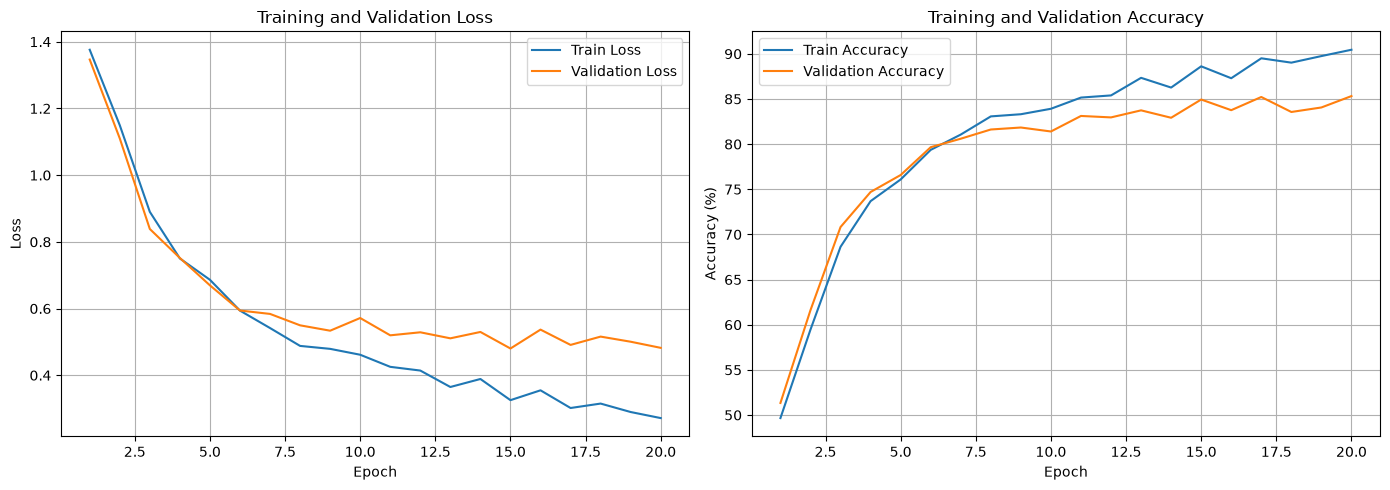

In [27]:
# 绘制训练/验证损失和准确率曲线
trainer.plot(acc=True)  # acc=True 表示分类任务，绘制损失+准确率双图

## 13. 验证集评估


In [28]:
# 在验证集上评估训练好的最优模型
# 说明: Trainer 在训练结束后会自动加载早停保存的最优权重（best_model_cifar10.pth），
#       因此这里评估的是整个训练过程中验证准确率最高的那个模型。
val_loss, val_acc = trainer.evaluating(val_loader)  # 计算验证集平均损失与准确率
print(f"\n========== SimpleConvNet 验证集评估结果 ==========")  # 打印分隔标题
print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}%")  # 打印验证损失与准确率


========== SimpleConvNet 验证集评估结果 ==========
Val Loss: 0.4822, Val Accuracy: 85.32%
